In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rail_df = pd.read_excel("../data/data_old/Patstitchcat_V300icat557ipat1.xlsx")

In [3]:
rail_df.head()

,Distance [m],Acceleration,Displacement,Force(20Hz),Force(raw)
0,55.083333,0.000005,1.308507e-12,77.913254,0.000000
1,55.166667,-0.157598,-3.939424e-08,73.705511,1.121429
2,55.250000,-0.685137,-3.288717e-07,69.450909,4.878672
3,55.333333,-1.305193,-1.326615e-06,65.163900,9.306118
4,55.416667,-1.955772,-3.637183e-06,60.859190,13.969766


In [4]:
rail_df = rail_df.rename(index=str, columns={"Force(20Hz)": "Force","Force(raw)":"Raw_Force"})
rail_df.head()

,Distance [m],Acceleration,Displacement,Force,Raw_Force
0,55.083333,0.000005,1.308507e-12,77.913254,0.000000
1,55.166667,-0.157598,-3.939424e-08,73.705511,1.121429
2,55.250000,-0.685137,-3.288717e-07,69.450909,4.878672
3,55.333333,-1.305193,-1.326615e-06,65.163900,9.306118
4,55.416667,-1.955772,-3.637183e-06,60.859190,13.969766


In [5]:
rail_df.shape

(19141, 5)

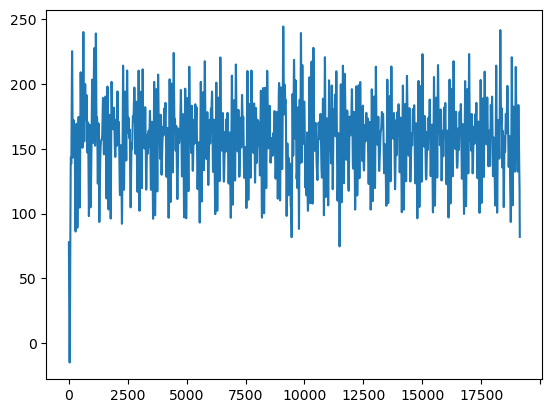

In [6]:
rail_df.Force.plot();

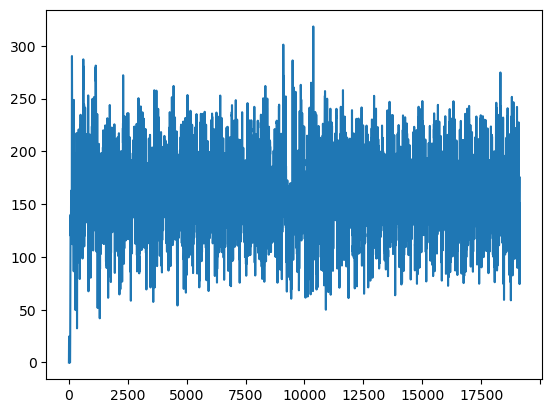

In [7]:
rail_df.Raw_Force.plot();

In [8]:
rail_df.shape

(19141, 5)

In [9]:
rail_df = rail_df.iloc[1000:18500]

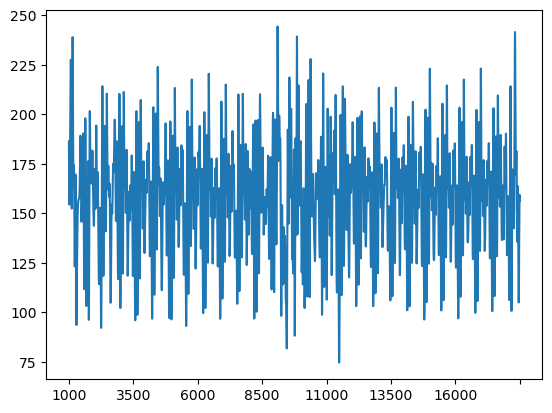

In [10]:
rail_df.Force.plot();

In [11]:
rail_v350 = pd.read_excel("../data/data_old/Patstitchcat_V350icat557ipat1.xlsx")
rail_v350 = rail_v350.rename(index=str, columns={"Force(20Hz)": "Force","Force(raw)":"Raw_Force"})
rail_v350 = rail_v350.iloc[1000:16000]

In [12]:
rail_df = pd.concat([rail_df,rail_v350])

In [13]:
rail_df.shape

(32500, 5)

In [14]:
from sklearn.svm import SVR

In [15]:
X = rail_df[['Acceleration','Displacement']]
y = rail_df.Raw_Force

In [16]:
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr_rbf.fit(X, y)

SVR(C=100, gamma=0.1)

## Testing

In [17]:
rail_v380 = pd.read_excel("../data/data_old/Patstitchcat_V380icat557ipat1.xlsx") # (15111, 5)
rail_v380 = rail_v380.rename(index=str, columns={"Force(20Hz)": "Force","Force(raw)":"Raw_Force"})
rail_v380 = rail_v380.iloc[800:14100]

In [21]:
X_pred = rail_v380[['Acceleration','Displacement']]
y_prime = rail_v380.Raw_Force

In [22]:
y_pred = svr_rbf.predict(X_pred)

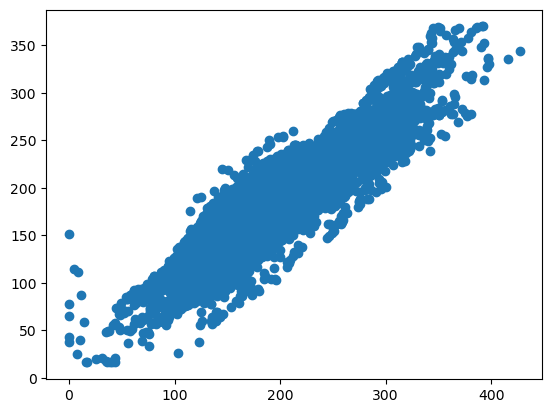

In [23]:
plt.scatter(y_prime,y_pred);

In [26]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from keras import regularizers
from keras.optimizers import RMSprop
from keras.layers import Bidirectional

2024-03-25 14:21:47.644054: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [27]:
reg = regularizers.l1_l2(0.01)
def rnn_model(steps=5,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Dense(2))
    model.add(Dense(32))
#     model.add(Bidirectional(SimpleRNN(16,return_sequences=req,dropout=0.5, recurrent_dropout=0.5,unroll=True,bias_regularizer=reg)))
    model.add(Dense(32))
    model.add(Dense(output_size))
    model.compile(loss='mean_squared_error')
    return model

rnn = rnn_model()
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
rnn_history = rnn.fit(rail_df[['Acceleration','Displacement']], rail_df.Force, epochs=20, verbose=2)

Epoch 1/50
1016/1016 - 2s - 2ms/step - loss: 9748.1670
Epoch 2/50
1016/1016 - 1s - 688us/step - loss: 850.6473
Epoch 3/50
1016/1016 - 1s - 667us/step - loss: 828.8755
Epoch 4/50
1016/1016 - 1s - 656us/step - loss: 805.2518
Epoch 5/50
1016/1016 - 1s - 701us/step - loss: 778.1339
Epoch 6/50
1016/1016 - 1s - 713us/step - loss: 746.5076
Epoch 7/50
1016/1016 - 1s - 715us/step - loss: 710.9632
Epoch 8/50
1016/1016 - 1s - 697us/step - loss: 676.7493
Epoch 9/50
1016/1016 - 1s - 688us/step - loss: 645.3181
Epoch 10/50
1016/1016 - 1s - 684us/step - loss: 618.0452
Epoch 11/50
1016/1016 - 1s - 664us/step - loss: 604.0732
Epoch 12/50
1016/1016 - 1s - 678us/step - loss: 597.1346
Epoch 13/50
1016/1016 - 1s - 767us/step - loss: 594.7404
Epoch 14/50
1016/1016 - 1s - 702us/step - loss: 592.6801
Epoch 15/50
1016/1016 - 1s - 692us/step - loss: 593.2629
Epoch 16/50
1016/1016 - 1s - 733us/step - loss: 591.9020
Epoch 17/50
1016/1016 - 1s - 704us/step - loss: 592.4440
Epoch 18/50
1016/1016 - 1s - 685us/step -

In [29]:
pred_value = rnn.predict(X_pred)

416/416 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


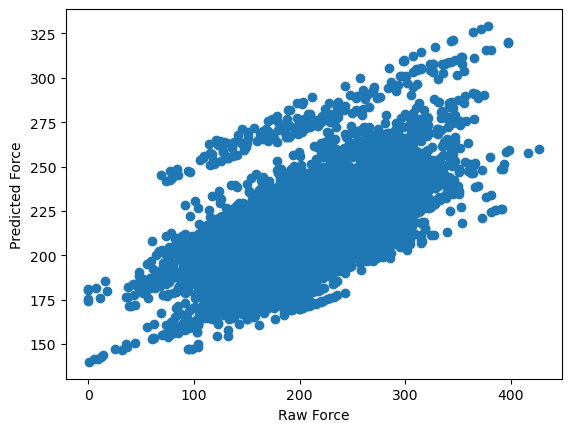

In [30]:
plt.scatter(y_prime,pred_value);
plt.xlabel("Raw Force")
plt.ylabel("Predicted Force");

In [31]:
def plot_slot(start=500,end=601):
    epoch_count = range(start,end)

    plt.plot(epoch_count, y_prime[start:end], 'r--',linewidth=2.0)
    plt.plot(epoch_count, y_pred[start:end], 'y--',linewidth=2.0)
    plt.plot(epoch_count, pred_value[start:end], 'b--',linewidth=2.0)
    plt.legend(['Raw Force', "SVR pred","DNN pred"])
    plt.xlabel('Time Slots')
    plt.ylabel('Force')
    #plt.title(title)
    plt.show()

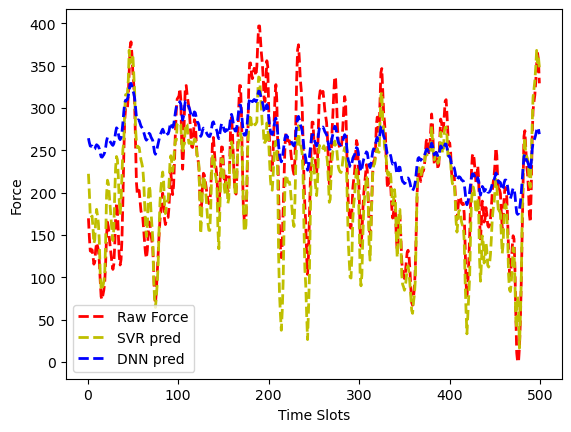

In [32]:
plot_slot(start=1,end=500)

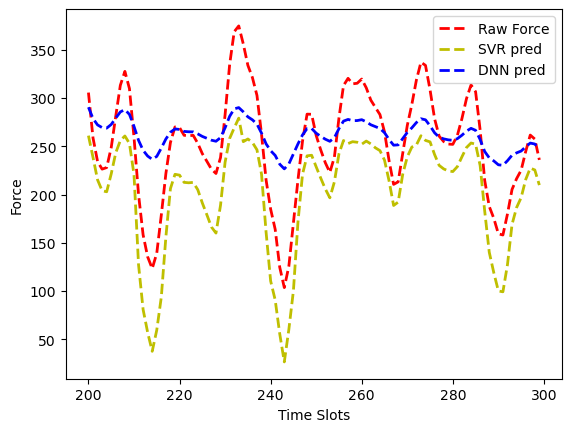

In [33]:
plot_slot(start=200,end=300)

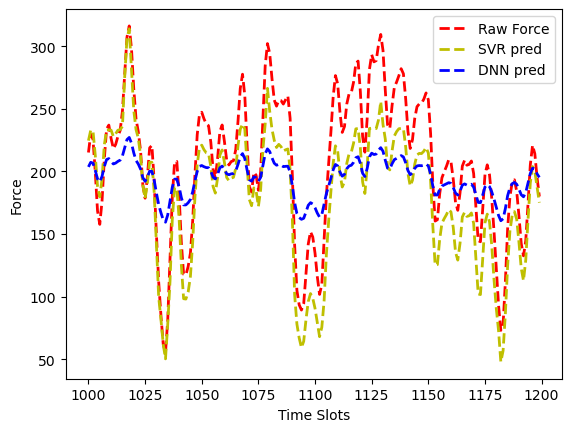

In [34]:
plot_slot(start=1000,end=1200)

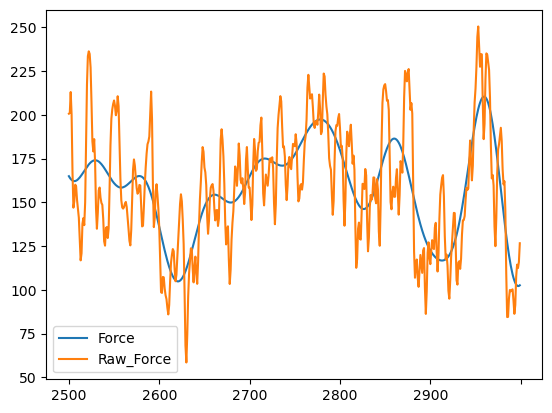

In [41]:
rail_df.iloc[1500:2000][["Force","Raw_Force"]].plot();

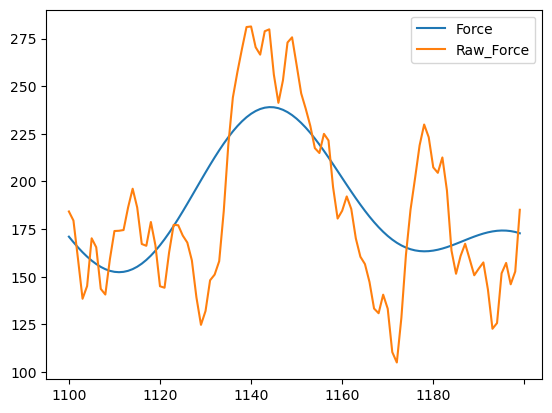

In [42]:
rail_df.iloc[100:200][["Force","Raw_Force"]].plot();

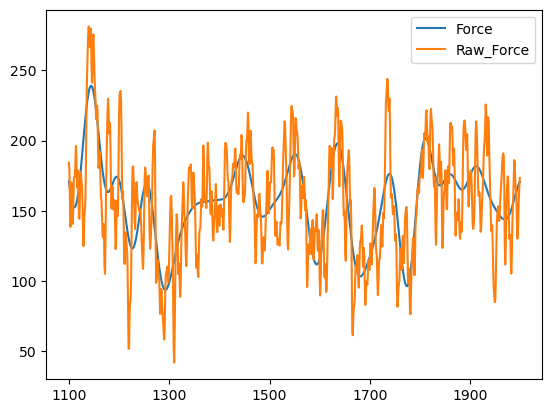

In [43]:
rail_df.iloc[100:1000][["Force","Raw_Force"]].plot();